In [2]:
#to prevent unnecessary warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
#import libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import subprocess
import cv2
import json
import requests


print(tf.__version__)

2.19.0


In [3]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images,train_labels),(test_images,test_labels) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print('Train images.shape:{}, of {}'.format(train_images.shape,train_images.dtype))
print('Test_images.shape: {}, of {}'.format(test_images.shape, test_images.dtype))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images.shape:(60000, 28, 28), of uint8
Test_images.shape: (10000, 28, 28), of uint8


#Reshape Data

In [4]:
#imagenet competition was for colored images hence 3 channels
train_images_3ch = np.stack([train_images]*3, axis=-1)
test_images_3ch = np.stack([test_images]*3,axis=-1)

print('Train images.shape: {}, of {}'.format(train_images_3ch.shape, train_images_3ch.dtype))
print('Test images.shape: {}, of {}'.format(test_images_3ch.shape, test_images_3ch.dtype))


Train images.shape: (60000, 28, 28, 3), of uint8
Test images.shape: (10000, 28, 28, 3), of uint8


#Resizing image

In [5]:
def resize_image_array(img, img_size_dims):
  img = cv2.resize(img, dsize=img_size_dims)
  img = np.array(img , dtype=np.float32)
  return img

In [6]:
IMG_DIMS = (32, 32)

train_images_3ch = np.array([resize_image_array(img, img_size_dims=IMG_DIMS) for img in train_images_3ch])
test_images_3ch = np.array([resize_image_array(img, img_size_dims=IMG_DIMS) for img in test_images_3ch])

print('\nTrain_images.shape: {}, of {}'.format(train_images_3ch.shape, train_images_3ch.dtype))
print('Test_images.shape: {}, of {}'.format(test_images_3ch.shape, test_images_3ch.dtype))


Train_images.shape: (60000, 32, 32, 3), of float32
Test_images.shape: (10000, 32, 32, 3), of float32


#**VGG**-**19**

In [7]:
#define input shape
INPUT_SHAPE = (32,32,3)

#get the vgg-19 model
vgg_layers = tf.keras.applications.vgg19.VGG19(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
#we are adding our own layer
vgg_layers.summary()
#include_top=False = we will add our own last layer

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

#**Build CNN on top of VGG19**

In [9]:
#define sequential model
model = tf.keras.models.Sequential()#This creates a Sequential model, which is a linear stack of layers.
#You’ll be adding layers one after another.

#add the vgg convulational model
model.add(vgg_layers)


#add flatten layer
model.add(tf.keras.layers.Flatten())

#Converts the 3D feature maps output from VGG19 into a 1D vector.

#Adds two fully connected layers with 256 neurons each.
#relu activation introduces non-linearity and helps learn complex features.
#Dropout(rate=0.3) randomly “drops” 30% of neurons during training to prevent overfitting.#

#add desne layer with some dropout
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dropout(rate=0.3))
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dropout(rate=0.3))

#add output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))

#compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
loss ='sparse_categorical_crossentropy',
metrics = ['accuracy'])

#view model layers
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 1, 1, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,224,074 (77.15 MB)

 Trainable params: 20,224,074 (77.15 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
EPOCHS = 5 #100 full passes through the dataset
train_images_3ch_scaled = train_images_3ch / 255 #raw pixrl values range from 0-255
#Dividing by 255 normalizes them to 0–1, which speeds up training and stabilizes gradients.
es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=2, restore_best_weights=True, verbose=1)

history = model.fit(train_images_3ch_scaled, train_labels, batch_size =32, callbacks=[es_callback],validation_split=0.1, epochs=EPOCHS, verbose=1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 122s 72ms/step - accuracy: 0.9277 - loss: 0.2090 - val_accuracy: 0.9185 - val_loss: 0.2304
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 143s 73ms/step - accuracy: 0.9343 - loss: 0.1823 - val_accuracy: 0.9257 - val_loss: 0.2040
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 141s 72ms/step - accuracy: 0.9436 - loss: 0.1589 - val_accuracy: 0.9265 - val_loss: 0.2169
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 143s 73ms/step - accuracy: 0.9494 - loss: 0.1466 - val_accuracy: 0.9297 - val_loss: 0.1984
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 122s 72ms/step - accuracy: 0.9539 - loss: 0.1308 - val_accuracy: 0.9337 - val_loss: 0.1928
Restoring model weights from the end of the best epoch: 5.


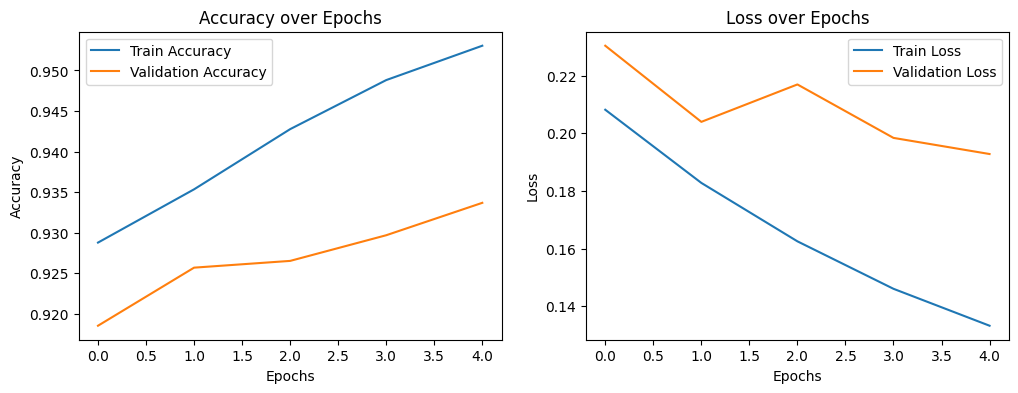

In [14]:
import pandas as pd
# plot training vs validation accuracy and loss
plt.figure(figsize=(12,4))
#accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = 'Train Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

#Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label = 'Train Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#Test Data Accuracy

In [16]:
test_images_3ch_scaled = test_images_3ch/255.
predictions = model.predict(test_images_3ch_scaled)
predictions[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


array([[9.6034602e-10, 1.3970607e-09, 6.8773787e-08, 3.5202874e-08,
        4.5477329e-08, 1.8622742e-07, 1.3785668e-08, 1.6998978e-05,
        4.2598702e-09, 9.9998260e-01],
       [1.8255200e-04, 6.5189130e-07, 9.9735343e-01, 1.0058655e-05,
        3.3589292e-04, 6.4305414e-07, 2.1078691e-03, 8.1397724e-07,
        4.1631556e-06, 3.9746483e-06],
       [7.2641244e-16, 1.0000000e+00, 1.8714139e-14, 9.2968307e-11,
        1.3249011e-11, 2.8027419e-14, 1.6730687e-12, 4.0689298e-14,
        2.1423538e-16, 6.5163181e-15],
       [9.0420744e-12, 1.0000000e+00, 6.7188234e-11, 5.9147791e-08,
        9.8072910e-09, 1.1075123e-10, 1.8896720e-09, 1.4450884e-10,
        2.9672753e-12, 3.5088796e-11],
       [2.2342095e-01, 3.2257332e-04, 8.4347054e-03, 4.0697930e-03,
        4.9981740e-03, 2.8662506e-04, 7.5752419e-01, 2.6365984e-04,
        5.4502743e-04, 1.3429581e-04]], dtype=float32)

In [17]:
prediction_labels = np.argmax(predictions, axis=1)
prediction_labels[:5]


array([9, 2, 1, 1, 6])

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

print(classification_report(test_labels,prediction_labels,target_names=class_names))
pd.DataFrame(confusion_matrix(test_labels, prediction_labels), index=class_names, columns=class_names)

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.90      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.89      0.91      0.90      1000
       Dress       0.94      0.91      0.93      1000
        Coat       0.86      0.92      0.89      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.82      0.76      0.79      1000
     Sneaker       0.96      0.98      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot
T-shirt/top,896,2,16,12,5,0,66,0,3,0
Trouser,0,989,0,4,3,0,3,0,1,0
Pullover,12,1,911,7,35,0,34,0,0,0
Dress,17,7,7,913,38,0,18,0,0,0
Coat,2,0,31,12,915,0,40,0,0,0
Sandal,0,0,0,0,0,993,0,5,0,2
Shirt,98,1,52,20,65,0,761,0,3,0
Sneaker,0,0,0,0,0,8,0,979,0,13
Bag,3,0,1,4,1,1,4,0,986,0
Ankle boot,0,0,0,0,0,2,1,36,0,961


In [19]:
print(test_labels[:100])

[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0 2 5 7 9 1 4 6 0 9 3 8 8 3 3 8 0 7
 5 7 9 6 1 3 7 6 7 2 1 2 2 4 4 5 8 2 2 8 4 8 0 7 7 8 5 1 1 2 3 9 8 7 0 2 6
 2 3 1 2 8 4 1 8 5 9 5 0 3 2 0 6 5 3 6 7 1 8 0 1 4 2]


#Accuracy is 0.93

# **RestNet50**

In [25]:
from threading import active_count
# define input shape
INPUT_SHAPE = (32,32,3)
#get the resnet50 model
ResNet50 = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
#we are adding our own layers
ResNet50.summary()
#define sequential model
model = tf.keras.models.Sequential()#This creates a Sequential model, which is a linear stack of layers.
#You’ll be adding layers one after another.
#add the resnet50 base model
model.add(ResNet50)

#add flatten layer
model.add(tf.keras.layers.Flatten())

#Converts the 3D feature maps output from VGG19 into a 1D vector.

#Adds two fully connected layers with 256 neurons each.
#relu activation introduces non-linearity and helps learn complex features.
#Dropout(rate=0.3) randomly “drops” 30% of neurons during training to prevent overfitting.#

# add dense layers with some dropout
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dropout(rate=0.3))
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dropout(rate=0.3))

#add output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))

#compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
loss = 'sparse_categorical_crossentropy',
metrics = ['accuracy'])

#view model layers
model.summary()



Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_9[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,180,618 (92.24 MB)

 Trainable params: 24,127,498 (92.04 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [26]:
EPOCHS = 5 #100 full passes through the dataset
train_images_3ch_scaled = train_images_3ch / 255 #raw pixrl values range from 0-255
#Dividing by 255 normalizes them to 0–1, which speeds up training and stabilizes gradients.
es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=2, restore_best_weights=True, verbose=1)

history = model.fit(train_images_3ch_scaled, train_labels, batch_size =32, callbacks=[es_callback],validation_split=0.1, epochs=EPOCHS, verbose=1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 131s 45ms/step - accuracy: 0.4527 - loss: 1.7233 - val_accuracy: 0.8447 - val_loss: 0.4455
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.8144 - loss: 0.5682 - val_accuracy: 0.8890 - val_loss: 0.3227
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.8643 - loss: 0.4069 - val_accuracy: 0.9012 - val_loss: 0.2754
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.8862 - loss: 0.3310 - val_accuracy: 0.9107 - val_loss: 0.2524
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.9060 - loss: 0.2763 - val_accuracy: 0.9135 - val_loss: 0.2356
Restoring model weights from the end of the best epoch: 5.


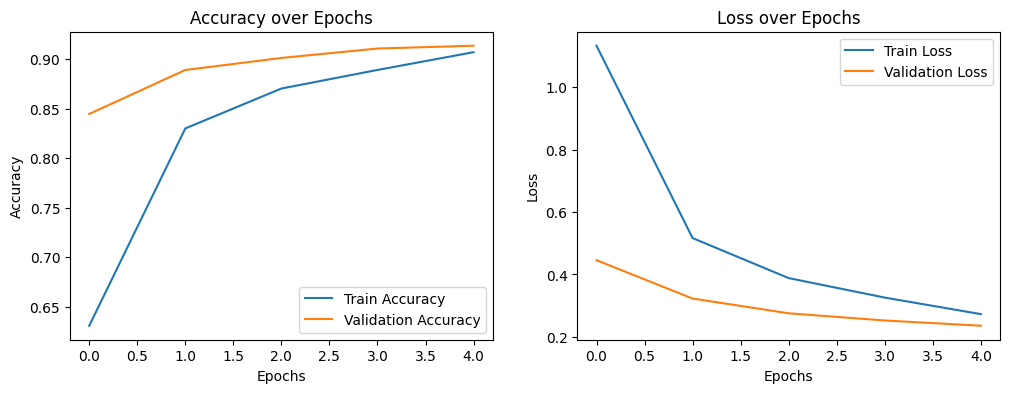

In [27]:
import pandas as pd
# plot training vs validation accuracy and loss
plt.figure(figsize=(12,4))
#accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = 'Train Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

#Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label = 'Train Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()